In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from PIL import Image

In [3]:
import pandas as pd

# Class ID to Class Name Mapping

CLASS_ID_TO_NAME = {
    "0": "other",
    "1": "crater",
    "2": "dark dune",
    "3": "slope streak",
    "4": "bright dune",
    "5": "impact ejecta",
    "6": "swiss cheese",
    "7": "spider"
}


# Function to read label file and convert to CSV

def convert_label_file_to_csv(label_file_path, output_csv_path):
    """
    Reads a label file with filename-class pairs and converts it to a CSV
    with columns: 'filename', 'class'.
    
    Parameters:
    - label_file_path: path to the input label text file
    - output_csv_path: path where CSV will be saved
    """
    records = []
    
    with open(label_file_path, "r") as file:
        for line in file:
            entries = line.strip().split()
            # Process each filename-class pair
            for idx in range(0, len(entries), 2):
                filename = entries[idx]
                class_id = entries[idx + 1]
                class_name = CLASS_ID_TO_NAME[class_id]
                records.append([filename, class_name])
    
    # Create DataFrame and save to CSV
    df = pd.DataFrame(records, columns=["filename", "class"])
    df.to_csv(output_csv_path, index=False)
    print(f"CSV created successfully at '{output_csv_path}'!")



# Usage
input_file = "labels-map-proj-v3.txt"
output_file = "landmarks_map-proj-v3_classmap.csv"
convert_label_file_to_csv(input_file, output_file)

CSV created successfully at 'landmarks_map-proj-v3_classmap.csv'!


In [4]:
import pandas as pd


# Paths

csv_path = "landmarks_map-proj-v3_classmap.csv"  # CSV generated earlier
images_folder = "map-proj-v3"                    # Directory containing images


# Load CSV

labels_df = pd.read_csv(csv_path)
print("First 5 rows of the dataset:")
print(labels_df.head())

print(f"\nTotal number of images: {len(labels_df)}")

First 5 rows of the dataset:
                            filename  class
0       ESP_011623_2100_RED-0069.jpg  other
1   ESP_011623_2100_RED-0069-r90.jpg  other
2  ESP_011623_2100_RED-0069-r180.jpg  other
3  ESP_011623_2100_RED-0069-r270.jpg  other
4    ESP_011623_2100_RED-0069-fh.jpg  other

Total number of images: 73031


In [5]:

# Convert class names to numeric labels
unique_classes = sorted(labels_df["class"].unique())
class_name_to_index = {name: idx for idx, name in enumerate(unique_classes)}

# Map class names to numeric labels in the DataFrame
labels_df["label"] = labels_df["class"].map(class_name_to_index)

# Display the mapping
print("Class name → Numeric label mapping:")
print(class_name_to_index)

Class name → Numeric label mapping:
{'bright dune': 0, 'crater': 1, 'dark dune': 2, 'impact ejecta': 3, 'other': 4, 'slope streak': 5, 'spider': 6, 'swiss cheese': 7}


In [6]:
from sklearn.model_selection import train_test_split

# Split dataset into train and test sets
train_df, test_df = train_test_split(
    labels_df,
    test_size=0.2,                 # 20% for testing
    stratify=labels_df["label"],   # maintain class distribution
    random_state=42                # reproducibility
)


# Quick overview
print(f"Number of training samples: {len(train_df)}")
print(f"Number of testing samples: {len(test_df)}")

Number of training samples: 58424
Number of testing samples: 14607


In [7]:
import tensorflow as tf

# Parameters
IMG_SIZE = 128
BATCH_SIZE = 32


# Image preprocessing function
def preprocess_image(image_path, label):
    """
    Reads an image from file, decodes, resizes, and normalizes it.
    
    Parameters:
    - image_path: path to the image file
    - label: numeric class label
    
    Returns:
    - tuple (processed_image, label)
    """
    # Read the image file
    image = tf.io.read_file(image_path)
    
    # Decode JPEG and ensure 3 channels (RGB)
    image = tf.image.decode_jpeg(image, channels=3)
    
    # Resize to standard size
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    
    # Normalize pixel values to [0,1]
    image = image / 255.0
    
    return image, label

In [8]:
import os
import pandas as pd
# Image directory

IMG_DIR = "map-proj-v3"

# Create full file path for each image

labels_df["filepath"] = labels_df["filename"].apply(
    lambda fname: os.path.join(IMG_DIR, fname)
)

# Convert class names to numeric labels

unique_classes = sorted(labels_df["class"].unique())
class_name_to_index = {name: idx for idx, name in enumerate(unique_classes)}

labels_df["label"] = labels_df["class"].map(class_name_to_index)

# Preview the DataFrame
print("Sample of processed dataset:")
print(labels_df.head())

Sample of processed dataset:
                            filename  class  label  \
0       ESP_011623_2100_RED-0069.jpg  other      4   
1   ESP_011623_2100_RED-0069-r90.jpg  other      4   
2  ESP_011623_2100_RED-0069-r180.jpg  other      4   
3  ESP_011623_2100_RED-0069-r270.jpg  other      4   
4    ESP_011623_2100_RED-0069-fh.jpg  other      4   

                                        filepath  
0       map-proj-v3/ESP_011623_2100_RED-0069.jpg  
1   map-proj-v3/ESP_011623_2100_RED-0069-r90.jpg  
2  map-proj-v3/ESP_011623_2100_RED-0069-r180.jpg  
3  map-proj-v3/ESP_011623_2100_RED-0069-r270.jpg  
4    map-proj-v3/ESP_011623_2100_RED-0069-fh.jpg  


In [9]:
from sklearn.model_selection import train_test_split

# Split dataset into train and test sets

train_df, test_df = train_test_split(
    labels_df,                   # full DataFrame with filepaths and labels
    test_size=0.2,               # 20% of data for testing
    stratify=labels_df["label"], # maintain class distribution
    random_state=42              # reproducibility
)

# Quick overview
print(f"Number of training samples: {len(train_df)}")
print(f"Number of testing samples: {len(test_df)}")

Number of training samples: 58424
Number of testing samples: 14607


In [10]:
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
# Stratified train-test split
train_df, test_df = train_test_split(
    labels_df,                  # full DataFrame with filepaths and labels
    test_size=0.2,
    random_state=42,
    stratify=labels_df["label"]
)

print("Train class distribution:\n", train_df["label"].value_counts())
print("Test class distribution:\n", test_df["label"].value_counts())


#  Create TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_df["label"].values)
)
test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["filepath"].values, test_df["label"].values)
)


# Preprocessing function

IMG_SIZE = 128

def preprocess_image(filepath, label):
    """Read, decode, resize, and normalize an image."""
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_ds = train_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)


# Shuffle, batch, and prefetch

BATCH_SIZE = 32

train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("TensorFlow datasets ready for training and testing")

Train class distribution:
 label
4    48842
1     3920
5     1865
0     1400
7      918
2      913
6      381
3      185
Name: count, dtype: int64
Test class distribution:
 label
4    12212
1      980
5      466
0      350
7      230
2      228
6       95
3       46
Name: count, dtype: int64
TensorFlow datasets ready for training and testing


[HAMI-core Msg(174:140435427028288:libvgpu.c:839)]: Initializing.....
[HAMI-core Msg(174:140435427028288:libvgpu.c:855)]: Initialized
I0000 00:00:1772478519.951013     174 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5874 MB memory:  -> device: 0, name: NVIDIA H200 NVL, pci bus id: 0000:8c:00.0, compute capability: 9.0


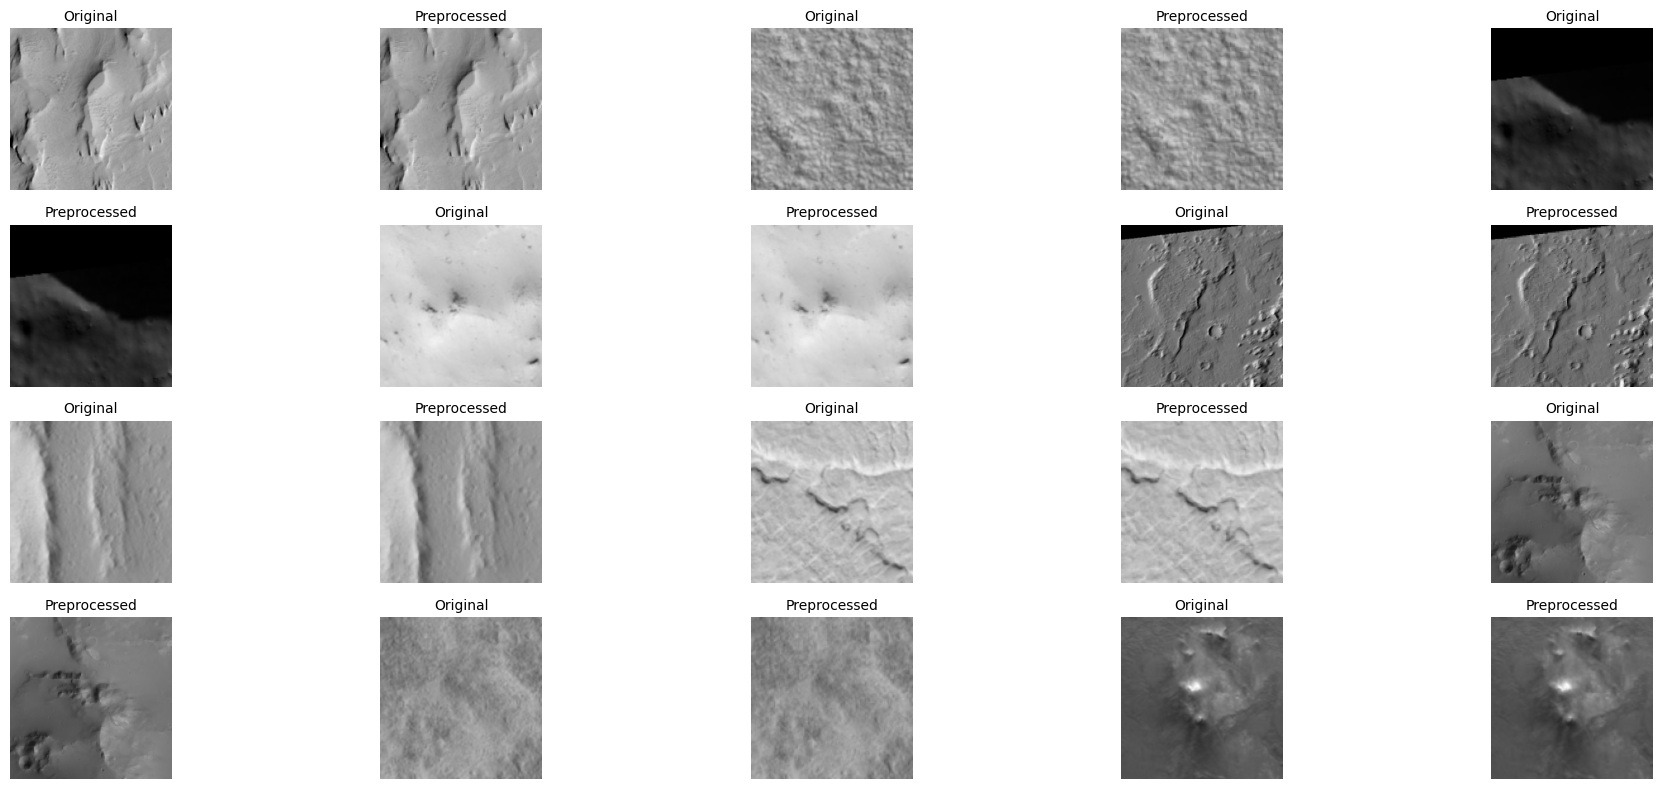

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
# Sample images
num_samples = 10
sample_df = labels_df.sample(num_samples)

# Each sample will show original + preprocessed
num_images = num_samples * 2
cols = 5  # images per row
rows = (num_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, 8))
axes = axes.flatten()  # flatten in case rows > 1

# Plot original and preprocessed images

for idx, (_, row) in enumerate(sample_df.iterrows()):
    # Original image
    orig_img = Image.open(row["filepath"]).convert("RGB")
    axes[idx*2].imshow(orig_img)
    axes[idx*2].set_title("Original", fontsize=10)
    axes[idx*2].axis("off")

    # Preprocessed image
    preproc_img = preprocess_image(row["filepath"], 0)[0].numpy()
    axes[idx*2 + 1].imshow(preproc_img)
    axes[idx*2 + 1].set_title("Preprocessed", fontsize=10)
    axes[idx*2 + 1].axis("off")

# Hide any remaining axes if grid is larger than number of images
for ax in axes[num_images:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
# Parameters

IMG_SIZE = 128
NUM_CLASSES = 8


# Data augmentation

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")


# CNN model
model = keras.Sequential([
    # Input layer explicitly defined
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input_layer"),

    # Data augmentation
    data_augmentation,

    # Convolutional block 1
    layers.Conv2D(32, (3,3), padding="same", activation="relu", name="conv1"),
    layers.MaxPooling2D((2,2), name="pool1"),

    # Convolutional block 2
    layers.Conv2D(64, (3,3), padding="same", activation="relu",
                  kernel_regularizer=regularizers.l2(1e-4), name="conv2"),
    layers.MaxPooling2D((2,2), name="pool2"),

    # Convolutional block 3
    layers.Conv2D(128, (3,3), padding="same", activation="relu",
                  kernel_regularizer=regularizers.l2(1e-4), name="conv3"),
    layers.MaxPooling2D((2,2), name="pool3"),

    # Flatten and fully connected layers
    layers.Flatten(name="flatten"),
    layers.Dense(256, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4), name="fc1"),
    layers.Dropout(0.3, name="dropout1"),

    # Output layer
    layers.Dense(NUM_CLASSES, activation="softmax", name="output")
], name="CNN_Model")


# Model summary
model.summary()

Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,168 (32.36 MB)

 Trainable params: 8,484,168 (32.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow import keras
# Compile the CNN model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # Adam optimizer with 0.001 LR
    loss="sparse_categorical_crossentropy",                # for integer labels
    metrics=["accuracy"]                                   # track accuracy
)

print(" Model compiled successfully!")

 Model compiled successfully!


In [14]:
from tensorflow.keras.callbacks import EarlyStopping

# Training parameters
NUM_EPOCHS = 18
PATIENCE = 5  # Early stopping patience

# Early stopping callback
early_stopping_callback = EarlyStopping(
    monitor="val_loss",          # track validation loss
    patience=PATIENCE,           # stop if no improvement for PATIENCE epochs
    restore_best_weights=True    # revert to best model weights
)

# Train the model
training_history = model.fit(
    train_ds,                      # training dataset
    validation_data=test_ds,       # validation dataset
    epochs=NUM_EPOCHS,
    callbacks=[early_stopping_callback]
)

# Training complete
print(" Model training is done!")

Epoch 1/18
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8412 - loss: 0.6470 - val_accuracy: 0.8489 - val_loss: 0.5642
Epoch 2/18
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8616 - loss: 0.5384 - val_accuracy: 0.8671 - val_loss: 0.5057
Epoch 3/18
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8722 - loss: 0.5008 - val_accuracy: 0.8782 - val_loss: 0.4586
Epoch 4/18
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8776 - loss: 0.4823 - val_accuracy: 0.8816 - val_loss: 0.4535
Epoch 5/18
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8815 - loss: 0.4673 - val_accuracy: 0.8838 - val_loss: 0.4419
Epoch 6/18
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8858 - loss: 0.4521 - val_accuracy: 0.8892 - val_loss: 0.4332
Epoch 7/18
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8891 - loss: 0.4424 - val_accuracy: 0.8881 - val_loss: 0.4287
Epoch 8/18
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8925 - loss: 0

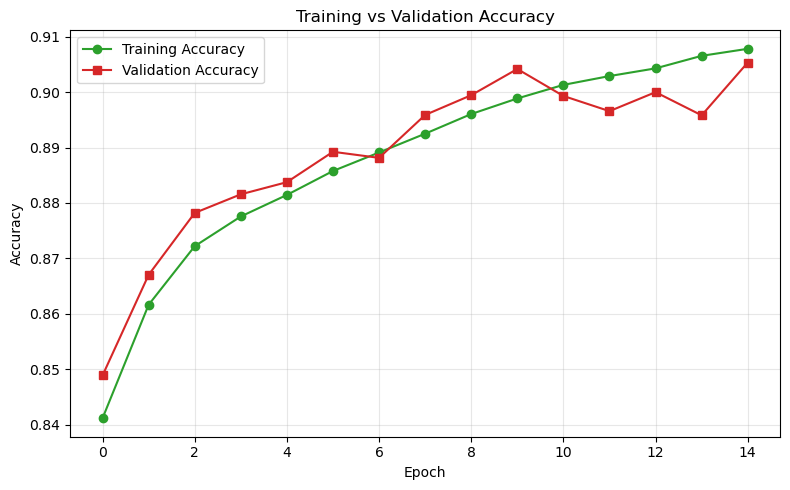

In [15]:
import matplotlib.pyplot as plt
# Plot training vs validation accuracy
train_acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']

fig, ax = plt.subplots(figsize=(8,5))

# Plot lines with distinct colors and markers
ax.plot(train_acc, marker='o', color='tab:green', label="Training Accuracy")
ax.plot(val_acc, marker='s', color='tab:red', label="Validation Accuracy")

# Labels and title
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Training vs Validation Accuracy")

# Legend and grid
ax.legend()
ax.grid(alpha=0.3)

# Save figure
fig.tight_layout()
fig.savefig("accuracy.png", dpi=300, bbox_inches="tight")

# Show plot
plt.show()

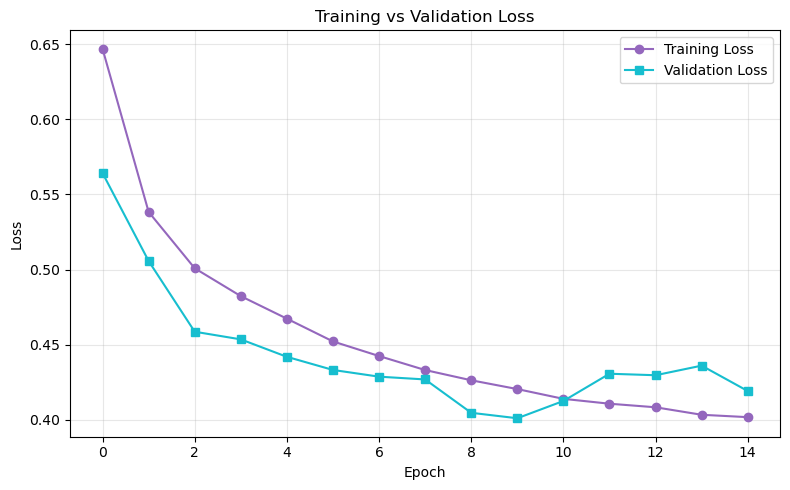

In [16]:
import matplotlib.pyplot as plt
# Plot training vs validation loss
train_loss_values = training_history.history['loss']
val_loss_values = training_history.history['val_loss']

fig, ax = plt.subplots(figsize=(8,5))

# Plot lines with distinct colors and markers
ax.plot(train_loss_values, marker='o', color='tab:purple', label="Training Loss")
ax.plot(val_loss_values, marker='s', color='tab:cyan', label="Validation Loss")

# Labels and title
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss")

# Legend and grid
ax.legend()
ax.grid(alpha=0.3)

# Save figure
fig.tight_layout()
fig.savefig("loss.png", dpi=300, bbox_inches="tight")

# Show plot
plt.show()

In [17]:

# Extract final epoch metrics
final_train_accuracy = training_history.history["accuracy"][-1]
final_val_accuracy   = training_history.history["val_accuracy"][-1]

final_train_loss = training_history.history["loss"][-1]
final_val_loss   = training_history.history["val_loss"][-1]

# Check overfitting (loss difference)
loss_diff = final_val_loss - final_train_loss

# Print final results
print("FINAL MODEL PERFORMANCE")
print(f"Training Accuracy   : {final_train_accuracy:.4f}")
print(f"Validation Accuracy : {final_val_accuracy:.4f}")
print(f"Training Loss       : {final_train_loss:.4f}")
print(f"Validation Loss     : {final_val_loss:.4f}")
print(f"Loss Difference (Val - Train) : {loss_diff:.4f}")


FINAL MODEL PERFORMANCE
Training Accuracy   : 0.9078
Validation Accuracy : 0.9053
Training Loss       : 0.4017
Validation Loss     : 0.4191
Loss Difference (Val - Train) : 0.0174


In [18]:
print(test_df.columns)
print(test_df.head())

Index(['filename', 'class', 'label', 'filepath'], dtype='object')
                                filename         class  label  \
52110  ESP_011677_1655_RED-0005-r180.jpg         other      4   
51011  ESP_013257_2110_RED-0222-r180.jpg         other      4   
68869  PSP_004673_0935_RED-0140-r270.jpg  swiss cheese      7   
8061     ESP_025151_1570_RED-0269-fh.jpg         other      4   
3095    ESP_012588_1855_RED-0368-r90.jpg         other      4   

                                            filepath  
52110  map-proj-v3/ESP_011677_1655_RED-0005-r180.jpg  
51011  map-proj-v3/ESP_013257_2110_RED-0222-r180.jpg  
68869  map-proj-v3/PSP_004673_0935_RED-0140-r270.jpg  
8061     map-proj-v3/ESP_025151_1570_RED-0269-fh.jpg  
3095    map-proj-v3/ESP_012588_1855_RED-0368-r90.jpg  


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


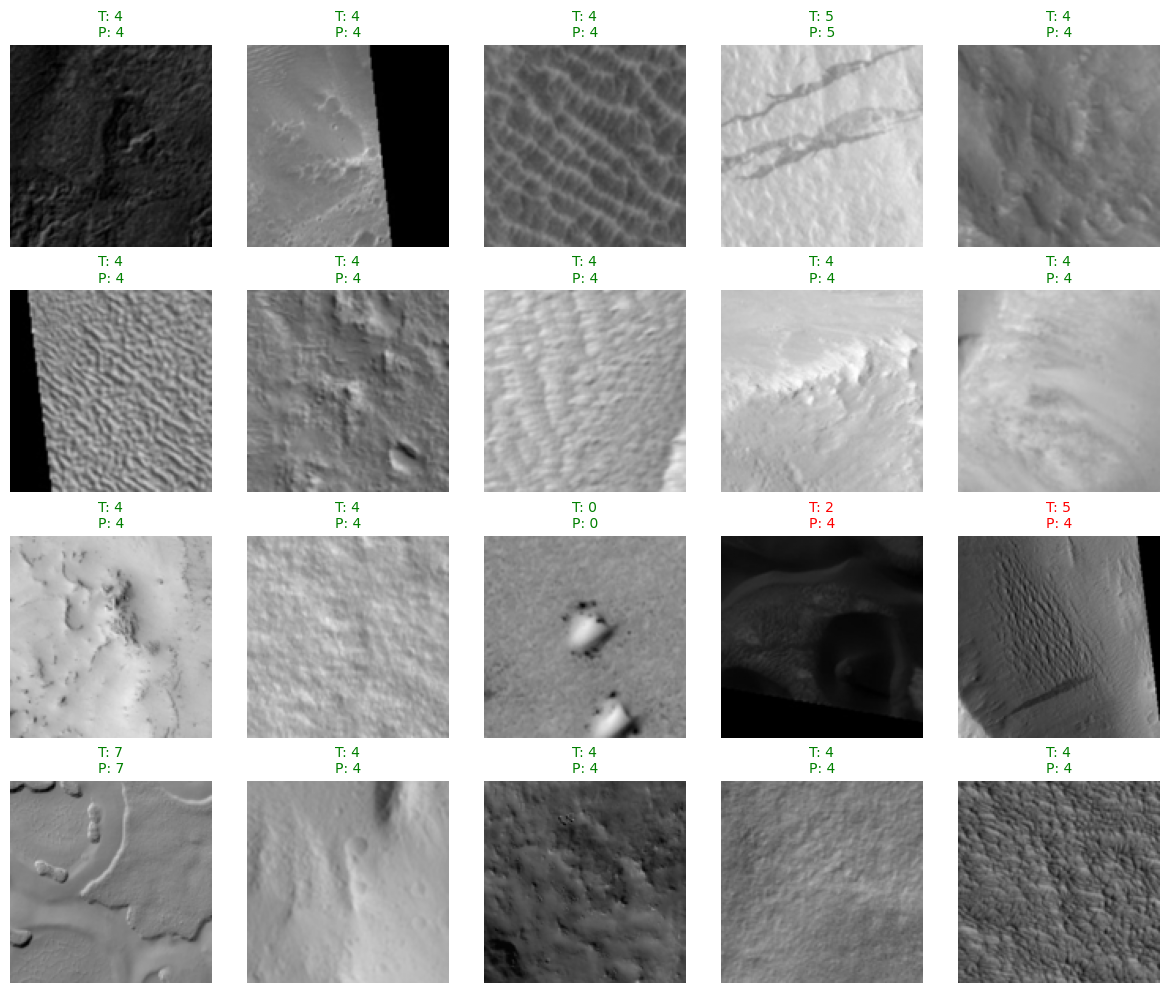

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
# Parameters
NUM_SAMPLES = 20
ROWS, COLS = 4, 5
IMG_SIZE = (128, 128)  
# Randomly sample from DataFrame
sample_df = test_df.sample(n=NUM_SAMPLES, random_state=42)
sample_images = []
sample_labels = []

for _, row in sample_df.iterrows():
    # Load image from filepath
    img = Image.open(row['filepath']).convert('RGB')
    img = img.resize(IMG_SIZE)
    img_array = np.array(img) / 255.0  # normalize
    sample_images.append(img_array)
    
    # True label
    sample_labels.append(row['label'])

# Plot predictions
plt.figure(figsize=(12, 10))

for i, (image, true_label) in enumerate(zip(sample_images, sample_labels)):
    # Predict
    predicted_label = np.argmax(model.predict(image[None, ...]), axis=1)[0]

    ax = plt.subplot(ROWS, COLS, i + 1)
    ax.imshow(image)  # already normalized, still works for plotting
    title_color = "green" if true_label == predicted_label else "red"
    ax.set_title(f"T: {true_label}\nP: {predicted_label}", color=title_color, fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

/tmp/ipykernel_174/2834536355.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn')


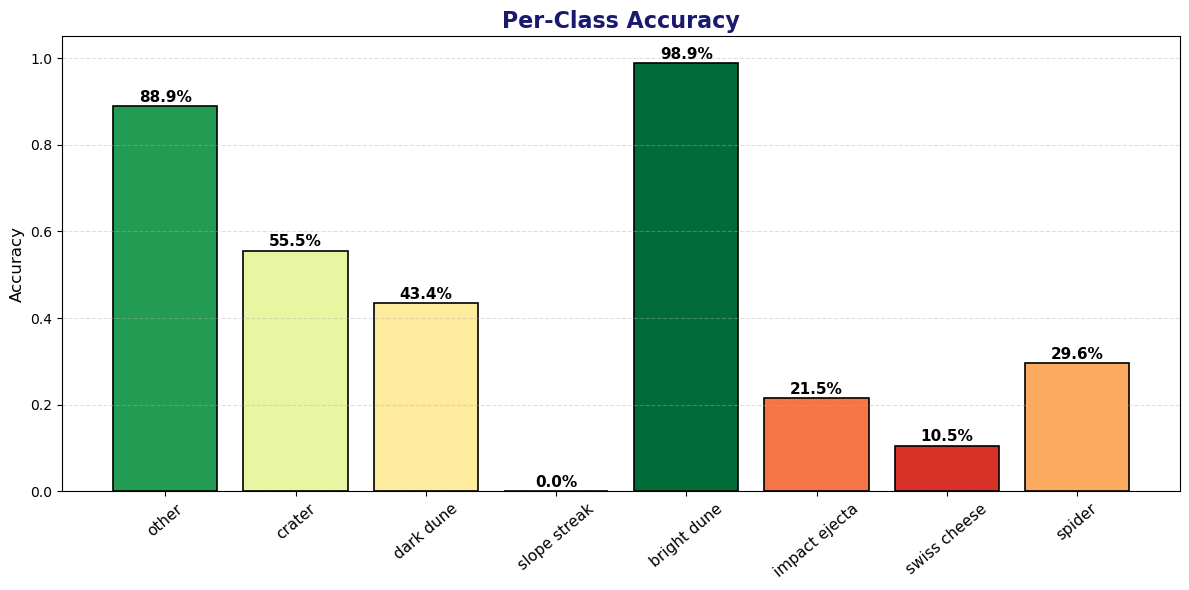

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
# Predict on the test dataset
true_labels = []
pred_labels = []

for batch_images, batch_labels in test_ds:
    batch_preds = model.predict(batch_images, verbose=0)
    true_labels.extend(batch_labels.numpy())
    pred_labels.extend(np.argmax(batch_preds, axis=1))

true_labels = np.array(true_labels)
pred_labels = np.array(pred_labels)

# Compute per-class accuracy
NUM_CLASSES = 8
CLASS_NAMES = [
    "other", "crater", "dark dune", "slope streak",
    "bright dune", "impact ejecta", "swiss cheese", "spider"
]

total_counts = np.array([np.sum(true_labels == i) for i in range(NUM_CLASSES)])
correct_counts = np.array([np.sum((true_labels == i) & (pred_labels == i)) for i in range(NUM_CLASSES)])
class_accuracies = correct_counts / total_counts


# Plotting

plt.figure(figsize=(12, 6))


cmap = plt.cm.get_cmap('RdYlGn')
bar_colors = cmap(class_accuracies)  # map accuracy to color

bars = plt.bar(CLASS_NAMES, class_accuracies, color=bar_colors, edgecolor="black", linewidth=1.2)

# Annotate accuracy on top of bars
for bar, acc in zip(bars, class_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc*100:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

plt.title(
    "Per-Class Accuracy",
    fontsize=16,
    fontweight="bold",
    color="midnightblue"
)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.05)

# Soft horizontal grid
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=40, fontsize=11)

plt.tight_layout()
plt.savefig("per_class_accuracy_colormap.png", dpi=300, bbox_inches="tight")
plt.show()